# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor
from utils import *
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Data Load & Review

In [ ]:
df_ins = pd.read_csv('data/insects.csv')
df_ins.sample(5)

In [4]:
data_review(df_ins)

{'Number of Rows': 178,
 'Number of Columns': 3,
 'Missing Values': 50,
 'Duplicate Values': 82}

In [5]:
df_temp = pd.read_csv('data/temperature.csv')
df_temp.sample(5)

,Date,Mean_Temperature,Temperature_Low,Temperature_High,Mean_Humidity
1823,07/08/2024,"25,74","23,5","27,4","62,64"
3118,14/08/2024,"26,18","24,9","27,7","56,83"
2677,19/08/2024,"19,14",19,"19,2","84,09"
1757,04/08/2024,"35,95","33,9","37,4","34,34"
1619,29/07/2024,"30,6","29,6","32,1","53,4"


In [6]:
data_review(df_temp)

{'Number of Rows': 3891,
 'Number of Columns': 5,
 'Missing Values': 0,
 'Duplicate Values': 0}

Data Preprocessing

# Data Preprocessing

In [7]:
df_ins.dropna(inplace=True)
df_ins.drop_duplicates(inplace=True)
df_ins['Date'] = pd.to_datetime(df_ins['Date'], format='mixed', dayfirst=True)

In [8]:
df_temp.dropna(inplace=True)
df_temp.drop_duplicates(inplace=True)
df_temp['Mean_Temperature'] = df_temp['Mean_Temperature'].str.replace(',', '.').astype(float)
df_temp['Temperature_High'] = df_temp['Temperature_High'].str.replace(',', '.').astype(float)
df_temp['Temperature_Low'] = df_temp['Temperature_Low'].str.replace(',', '.').astype(float)
df_temp['Mean_Humidity'] = df_temp['Mean_Humidity'].str.replace(',', '.').astype(float)
df_temp['Date'] = pd.to_datetime(df_temp['Date'], format='mixed', dayfirst=True)

In [9]:
df_merged = pd.merge(df_ins, df_temp, on='Date', how='left')
data_review(df_merged)

{'Number of Rows': 6069,
 'Number of Columns': 7,
 'Missing Values': 0,
 'Duplicate Values': 0}

In [10]:
df_grouped = df_merged.groupby('Date').agg({
    'Number_of_Insects': 'sum',
    'New_Catches': 'sum',
    'Mean_Temperature': 'mean',
    'Temperature_High': 'mean',
    'Temperature_Low': 'mean',
    'Mean_Humidity': 'mean'
}).reset_index()

# Descriptive Statistics

In [11]:
df_grouped.describe()

,Date,Number_of_Insects,New_Catches,Mean_Temperature,Temperature_High,Temperature_Low,Mean_Humidity
count,50,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2024-07-29 12:00:00,78.840000,37.800000,26.912766,27.786099,26.037610,62.275523
min,2024-07-05 00:00:00,0.000000,0.000000,20.345000,20.585714,20.114286,44.415190
25%,2024-07-17 06:00:00,0.000000,0.000000,26.223503,27.102892,25.341667,55.464396
50%,2024-07-29 12:00:00,24.000000,0.000000,27.031333,27.962624,26.040625,62.036938
75%,2024-08-10 18:00:00,120.000000,48.000000,27.959917,28.772083,27.093333,67.877844
max,2024-08-23 00:00:00,720.000000,600.000000,30.307250,31.105063,29.508333,88.884286
std,NaN,141.985967,100.313183,2.039379,2.107677,1.973498,9.046162


# Statistical Analysis of Variables

**Univariate Analysis**

In [12]:
cols = ['Number_of_Insects', 'New_Catches', 'Mean_Temperature', 'Temperature_Low', 'Temperature_High', 'Mean_Humidity']

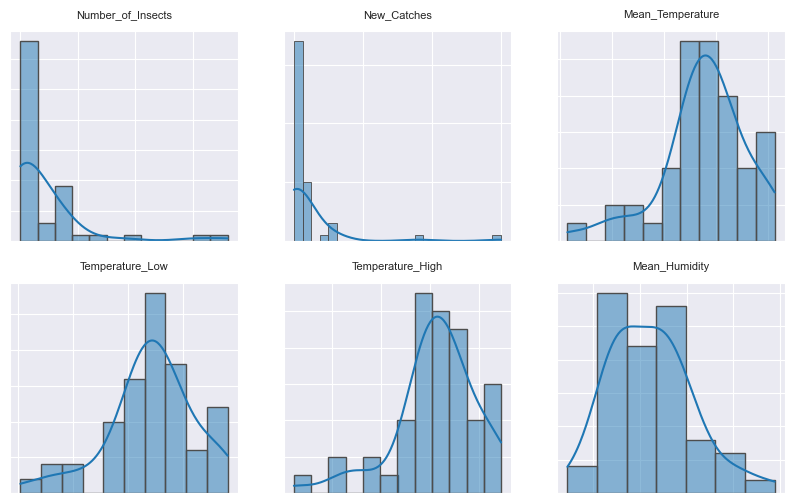

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
  sns.histplot(data=df_grouped, x=cols[i], kde=True, ax=ax, edgecolor = ".3")

  ax.set_title(f'{cols[i]}', pad=10, fontsize=8)
  ax.set_xlabel("")
  ax.set_ylabel("")
  ax.set_xticklabels("")
  ax.set_yticklabels("")
  ax.tick_params(axis='both', which='both', bottom=False, left=False)

**Observation:** It appears that the data in the features do not follow a normal distribution. To assess this further, we will visualize the Q-Q plots of the features.

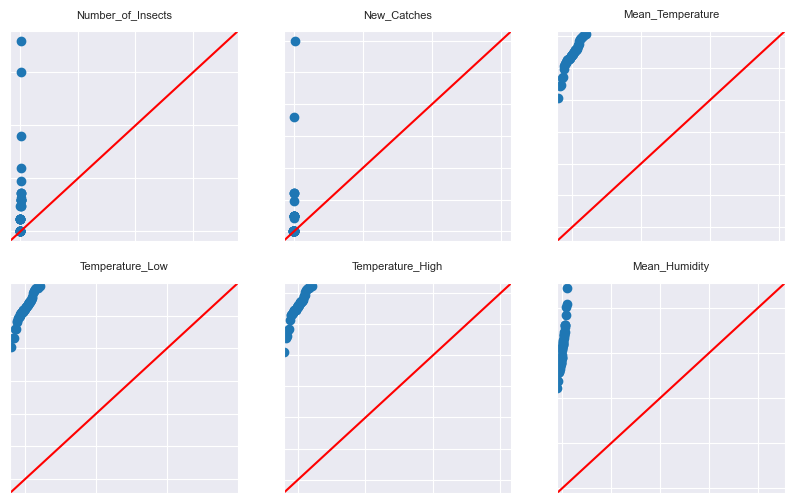

In [14]:
fig, axes = plt.subplots(2, 3, figsize = (10, 6))

for i, ax in enumerate(axes.flat):
        sm.qqplot(data = df_grouped[cols[i]], ax = ax, line = "45")
        ax.set_title(f'{cols[i]}', pad=10, fontsize=8)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(axis='both', which='both', bottom=False, left=False)
        ax.set_xlabel("")
        ax.set_ylabel("")

**Observation:** The data features show deviations from a normal distribution, as indicated by the Q-Q plots. To make the features more comparable, we will standardize the values

**Correlation Analysis**

In [15]:
cmap = mcolors.LinearSegmentedColormap.from_list('custom_blue', ['#FFFFFF', '#84ACC8'])

corr_matrix = round(df_grouped[cols].corr(), 2)
corr_matrix['New_Catches'].sort_values(ascending=False)

New_Catches          1.00
Number_of_Insects    0.84
Mean_Humidity        0.37
Temperature_Low     -0.25
Temperature_High    -0.25
Mean_Temperature    -0.26
Name: New_Catches, dtype: float64

**Observation:** There is no significant linear relationship between the target variables and the predictors, except for 'Number_of_Insects,' where the relationship is strong and positive.

<Axes: >

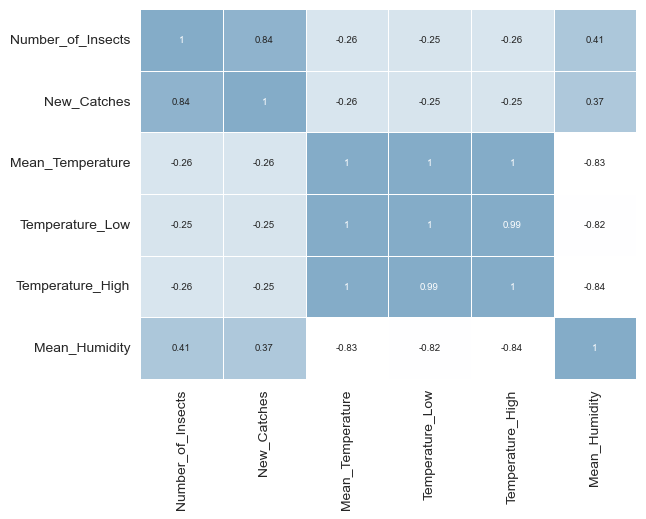

In [16]:
sns.heatmap(corr_matrix, annot = True, cmap = cmap, linewidths = 0.5, annot_kws={"size": 7}, cbar=False)

**Observation:** Since there seems to be multicollinearity between the three temperature features, we will remove the high and low temperature features.

In [17]:
df_grouped.drop(columns=['Temperature_High', 'Temperature_Low'], inplace=True)

# Data Visualization

Components of the Time-Series

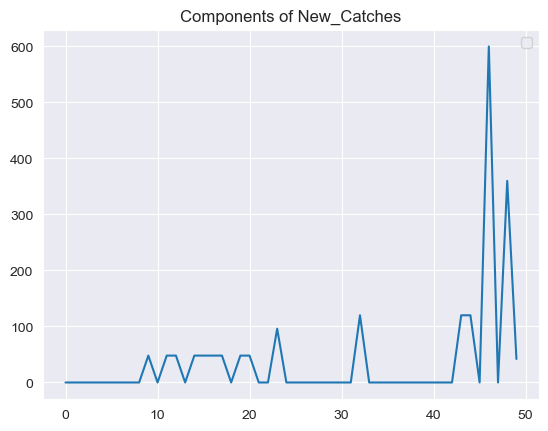

In [18]:
plot_series(df_grouped['New_Catches'], df_grouped['New_Catches'], label='', title='Components of New_Catches')

**Observation:** The data shows seasonality with peaks and troughs at regular intervals, along with a potential upward trend towards the end of the period. We will decompose the series into individual components to verify that.

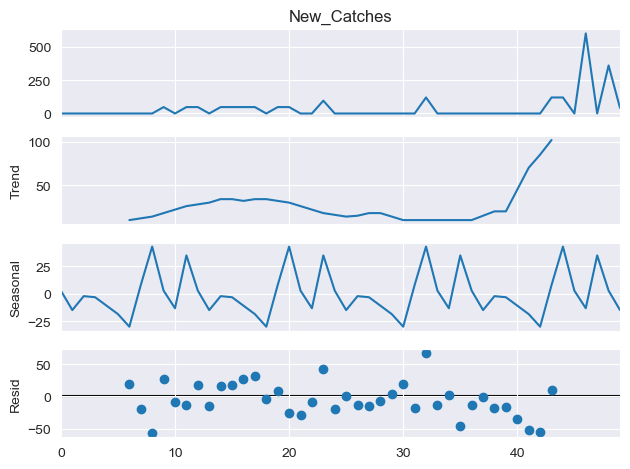

In [19]:
result = seasonal_decompose(df_grouped['New_Catches'], model='additive', period=12)  # Adjust 'period' based on your data frequency

result.plot()
plt.tight_layout()

**Observation:** 

Trend: Shows a gradual upward movement, indicating an increase in catches over time.

Seasonal: Reveals regular cyclical patterns with consistent peaks and troughs.

Residual: Displays random fluctuations around zero, suggesting the model has captured most patterns.








# Fixed Paritioning

Since the data is not sorted by date, we will do that before partitioning it for training and validation sets.

In [20]:
df_grouped["Date"].value_counts().sort_values(ascending=True)
df_grouped["Date"].shape

(50,)

In [21]:
n_train_samples = 40

X_train = df_grouped[0:n_train_samples]
X_val = df_grouped[n_train_samples:]

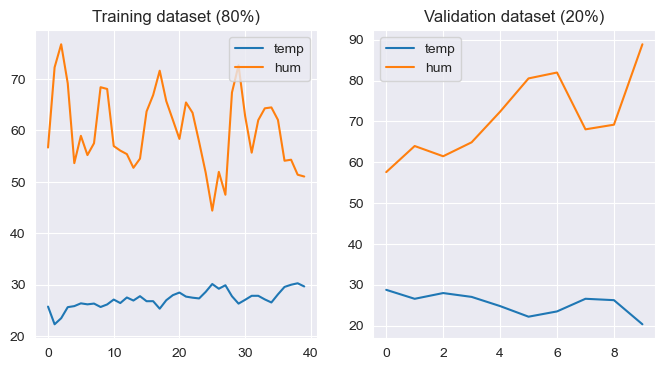

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

plt.sca(ax[0])
plot_series(X_train[['Mean_Temperature', 'Mean_Humidity']], X_train[['Mean_Temperature', 'Mean_Humidity']], label=['temp', 'hum'], title='Training dataset (80%)')

plt.sca(ax[1])
plot_series(X_val[['Mean_Temperature', 'Mean_Humidity']], X_val[['Mean_Temperature', 'Mean_Humidity']], label=['temp', 'hum'], title='Validation dataset (20%)')

# Statistical Forecast Methods

**Naive Forecast:** A simple, baseline method for making predictions. It assumes that the future will look like the past.

In [23]:
naive_forecast = df_grouped['New_Catches'].iloc[n_train_samples - 1:-1]
time_step = 8

print(f"Ground truth at time step {time_step}: {X_val['New_Catches'].iloc[time_step]}")
print(f"Prediction at time step {time_step + 1}: {naive_forecast.iloc[time_step + 1]}")

Ground truth at time step 8: 360.0
Prediction at time step 9: 360.0


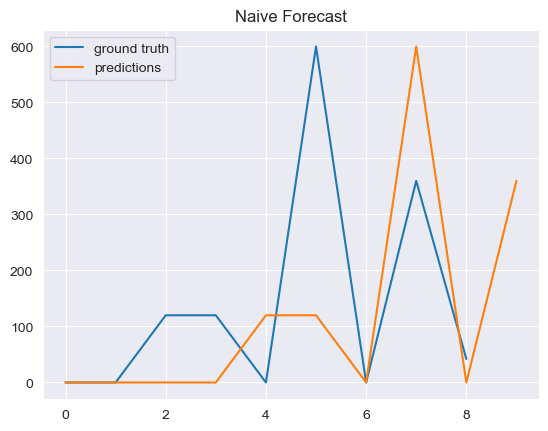

In [24]:
plot_series(X_val['New_Catches'].iloc[1:10], X_val['New_Catches'].iloc[1:10], label='ground truth', title='Naive Forecast')
plot_series(naive_forecast.iloc[0:10], naive_forecast.iloc[0:10], label='predictions', title='Naive Forecast')

**Observation:** It is clear that the predicted values are shifted by one time-step ahead of the actual values.

In [25]:
calculate_mae(X_val['New_Catches'], naive_forecast, 'Naive Forecast')

Naive Forecast:
MAE: 211.8


**Moving Average Forecast:** A forecasting technique that predicts future values by averaging a fixed number of past observations to smooth out short-term fluctuations and highlight longer-term trends.

In [26]:
window_size = 3

moving_avg = df_grouped['New_Catches'].rolling(window=window_size).mean()
moving_avg = moving_avg.iloc[n_train_samples:]

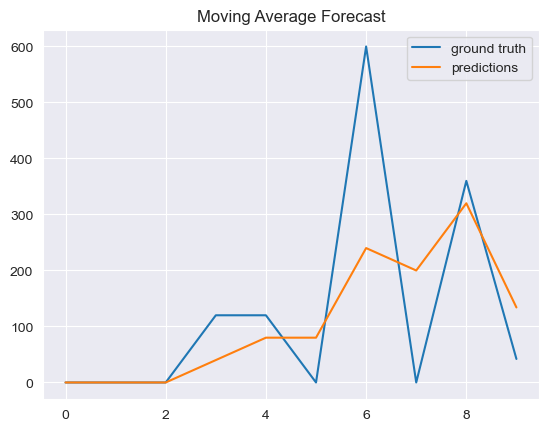

In [27]:
plot_series(X_val['New_Catches'].iloc[0:10], X_val['New_Catches'].iloc[0:10], label='ground truth', title='Moving Average Forecast')
plot_series(moving_avg.iloc[0:10], moving_avg.iloc[0:10], label='predictions', title='Moving Average Forecast')

In [28]:
calculate_mae(X_val['New_Catches'], moving_avg, 'Moving Average Forecast')

Moving Average Forecast:
MAE: 89.2


**Differenced Moving Average Forecast:** A time series transformation technique that subtracts the current observation from a previous one to achieve stationarity by removing trends and seasonality.

In [29]:
periods = 2
diff_series = df_grouped['New_Catches'].diff(periods=periods)

# Slice the prediction points corresponding to the validation set time steps.
diff_series = diff_series.iloc[n_train_samples:]

In [30]:
diff_moving_avg = diff_series.rolling(window=window_size).mean()
print('Null values after creating the moving average:', diff_moving_avg.isnull().sum())
diff_moving_avg = diff_moving_avg.bfill()
diff_moving_avg.isnull().sum()

Null values after creating the moving average: 2


0

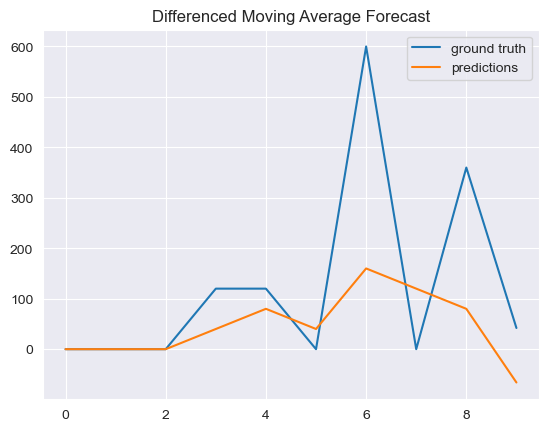

In [31]:
plot_series(X_val['New_Catches'].iloc[0:10], X_val['New_Catches'].iloc[0:10], label='ground truth', title='Differenced Moving Average Forecast')
plot_series(diff_moving_avg.iloc[0:10], diff_moving_avg.iloc[0:10], label='predictions', title='Differenced Moving Average Forecast')

In [32]:
calculate_mae(X_val['New_Catches'], diff_moving_avg, 'Difference Moving Average Forecast')

Difference Moving Average Forecast:
MAE: 110.8


# ARIMA

In [33]:
df_grouped.head()

,Date,Number_of_Insects,New_Catches,Mean_Temperature,Mean_Humidity
0,2024-07-05,0.0,0.0,25.777778,56.674444
1,2024-07-06,0.0,0.0,22.342500,72.247500
2,2024-07-07,0.0,0.0,23.517917,76.728750
3,2024-07-08,0.0,0.0,25.669167,69.143750
4,2024-07-09,0.0,0.0,25.870000,53.647083


In [34]:
df_grouped['Date'] = pd.to_datetime(df_grouped['Date'])
df_grouped.set_index('Date', inplace=True)

In [35]:
result = adfuller(df_grouped['New_Catches'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Statistic: -1.2358693736217208
p-value: 0.6579784922278517


**Observation:** The p-value is greater than 0.05 (0.6579), the time series is non-stationary.

In [36]:
df_grouped['New_Catches_diff'] = df_grouped['New_Catches'] - df_grouped['New_Catches'].shift(1)
df_grouped['New_Catches_diff'].dropna(inplace=True)

In [37]:
result = adfuller(df_grouped['New_Catches_diff'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Statistic: -8.925257916570239
p-value: 1.0153872562169785e-14


**Observation:** The p-value is now very small, indicating that the differenced series is stationary.

We will use auto-Arima to get the best values for p, d, and q.
    
p is about using previous data to predict the next value.
d is about making the data more stable by removing trends.
q is about correcting the predictions based on past mistakes.

In [38]:
model = auto_arima(df_grouped['New_Catches'].dropna(), seasonal=False, stepwise=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=610.479, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=612.218, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=612.351, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=606.873, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=591.879, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=592.694, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=593.169, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=587.597, Time=0.09 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=594.091, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=594.729, Time=0.07 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=591.471, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=587.810, Time=0.18 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fi

In [39]:
model = ARIMA(df_grouped['New_Catches'], order=(1, 0, 2))
fitted_model = model.fit()

Text(0.5, 1.0, 'Original vs In-sample Predictions')

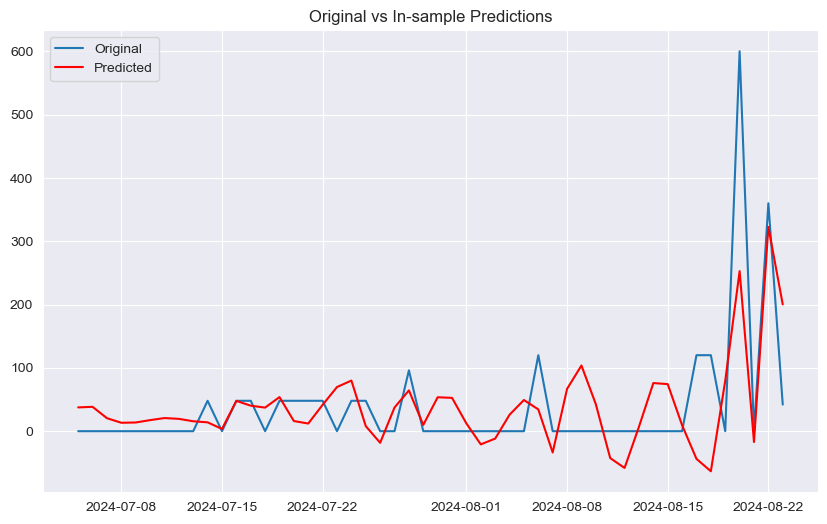

In [40]:
# In-sample prediction
predictions = fitted_model.predict(start=0, end=len(df_grouped['New_Catches'])-1)

# Plot the original and predicted values
plt.figure(figsize=(10, 6))
plt.plot(df_grouped['New_Catches'], label='Original')
plt.plot(df_grouped.index, predictions, label='Predicted', color='red')
plt.legend()
plt.title('Original vs In-sample Predictions')

In [41]:
calculate_mae(df_grouped['New_Catches'], predictions, 'ARIMA')

ARIMA:
MAE: 48.21812020460542


# Machine Learning Models

Feature Engineering

Day of the Year: Identifies yearly patterns.
Day of the Week: Captures weekly trends.
Week of the Year: Tracks seasonal changes by week.
Lag_1, Lag_2, Lag_3: Uses past catches to predict future ones.
Rolling Mean_7: Smooths data to highlight long-term trends.
Temp_Humidity_Interaction: Shows how temperature and humidity together affect catches.

In [130]:
df_grouped['Day_of_Year'] = df_grouped.index.dayofyear
df_grouped['Day_of_Week'] = df_grouped.index.dayofweek
df_grouped['Week_of_Year'] = df_grouped.index.isocalendar().week
df_grouped['Lag_1'] = df_grouped['New_Catches'].shift(1)
df_grouped['Lag_2'] = df_grouped['New_Catches'].shift(2)
df_grouped['Lag_3'] = df_grouped['New_Catches'].shift(3)
df_grouped['Rolling_Mean_7'] = df_grouped['New_Catches'].rolling(window=2).mean()
df_grouped['Temp_Humidity_Interaction'] = df_grouped['Mean_Temperature'] * df_grouped['Mean_Humidity']

In [131]:
X = df_grouped.drop(columns=['New_Catches'])
y = df_grouped['New_Catches']

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

In [148]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [152]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
calculate_mae(y_test, y_pred, 'Random Forest Regressor')

Random Forest Regressor:
MAE: 95.64


In [138]:
from prophet import Prophet

In [162]:
df_grouped_reset = df_grouped.reset_index()
prophet_data = df_grouped_reset[['Date', 'New_Catches']].rename(columns={'Date': 'ds', 'New_Catches': 'y'})
prophet_data.head()

,ds,y
0,2024-07-05,0.0
1,2024-07-06,0.0
2,2024-07-07,0.0
3,2024-07-08,0.0
4,2024-07-09,0.0


In [171]:
m = Prophet()
m.fit(prophet_data)

16:25:50 - cmdstanpy - INFO - Chain [1] start processing
16:25:51 - cmdstanpy - INFO - Chain [1] done processing


In [179]:
future = m.make_future_dataframe(periods=10)
future

,ds
0,2024-07-05
1,2024-07-06
2,2024-07-07
3,2024-07-08
4,2024-07-09
5,2024-07-10
6,2024-07-11
7,2024-07-12
8,2024-07-13
9,2024-07-14


In [182]:
forecast = m.predict(future)
forecast[['ds', 'yhat']]

,ds,yhat
0,2024-07-05,-43.176451
1,2024-07-06,-22.654863
2,2024-07-07,-2.088803
3,2024-07-08,-39.792528
4,2024-07-09,63.036647
5,2024-07-10,-32.936781
6,2024-07-11,11.622722
7,2024-07-12,-27.625137
8,2024-07-13,-7.103549
9,2024-07-14,13.462511


In [184]:
merged_data = pd.merge(prophet_data, forecast[['ds', 'yhat']], on='ds', how='left')
calculate_mae(merged_data['y'], merged_data['yhat'], 'Prophet')

Prophet:
MAE: 54.32554410842393
